## Rotary Power Spectra and CTD Profiles near Terra Nova Bay 

In [1]:
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np 
from scipy.signal import welch, csd
import pandas as pd


### Rotary Power Spectra 

**Goal:** Apply correlation and spectral relations to a vector timeseries (i.e. ocean currents) that is influenced by Earth's rotation. Earth's rotation can cause an asymmetry in fourier coefficients and we seek statistical relations that are invariant to rotation. 

A given velocity can be decomposed into a real and imaginary part, 

$$ u = u + iv $$

where $ i = \sqrt{-1} $

In Gonella (1972), four quantities are deemed useful: 

1. The mean kinetic energy (i.e. the total spectrum)

2. The rotary coefficient 

3. The orientation of the ellipse 

4. The stability of the ellipse 

Expanding on these, 

The mean kinetic energy, or the total spectrum, is defined as the summation of the clockwise ($ S_{-} $) and counterclockwise ($ S_{+} $) spectrums, 

$$ S_{t} = S_{-} + S_{+} $$

The rotary coefficient is defined as, 

$$ C_{R} = (S_{-} - S_{+}) / (S_{-} + S_{+}) $$



In [2]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import welch, csd

# def rotary_spectrum(u, v, fs, nperseg=256, **kwargs):
#     """
#     Compute the rotary power spectrum of 2D current data.

#     Parameters
#     ----------
#     u : array-like  — eastward velocity
#     v : array-like  — northward velocity
#     fs : float      — sampling frequency (Hz)
#     nperseg : int   — samples per Welch segment

#     Returns
#     -------
#     freq : ndarray  — frequencies (Hz), positive only
#     S_ccw : ndarray — CCW (counter-clockwise) spectrum
#     S_cw  : ndarray — CW  (clockwise) spectrum
#     """
#     # Auto- and cross-spectra using Welch's method
#     freq, Suu = welch(u, fs=fs, nperseg=nperseg, **kwargs)
#     _,    Svv = welch(v, fs=fs, nperseg=nperseg, **kwargs)
#     _,    Cuv = csd (u, v, fs=fs, nperseg=nperseg, **kwargs)  # complex cross-spectrum

#     # Rotary components
#     # S_ccw = (Suu + Svv + 2*Im(Cuv)) / 4   (CCW / positive freq)
#     # S_cw  = (Suu + Svv - 2*Im(Cuv)) / 4   (CW  / negative freq)
#     S_ccw = (Suu + Svv + 2 * np.imag(Cuv)) / 4
#     S_cw  = (Suu + Svv - 2 * np.imag(Cuv)) / 4

#     return freq, S_ccw, S_cw


# def rotary_coefficient(S_ccw, S_cw):
#     """
#     Rotary coefficient: +1 = pure CCW, -1 = pure CW, 0 = linear.
#     """
#     return (S_ccw - S_cw) / (S_ccw + S_cw)


# # --- Example usage ---
# fs = 1 / 3600          # 1-hour sampling → fs in Hz
# N  = 4096
# t  = np.arange(N) / fs

# # Synthetic inertial oscillation (CW in Northern Hemisphere)
# f_inertial = 1 / (18 * 3600)   # ~18-hour period
# u =  np.cos(2 * np.pi * f_inertial * t) + 0.1 * np.random.randn(N)
# v = -np.sin(2 * np.pi * f_inertial * t) + 0.1 * np.random.randn(N)

# freq, S_ccw, S_cw = rotary_spectrum(u, v, fs=fs, nperseg=512,
#                                     window='hann', detrend='linear')

# # Convert freq to cycles per day for oceanographic convention
# cpd = freq * 86400

# # --- Plot ---
# fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# ax = axes[0]
# ax.semilogy(cpd, S_ccw, label='CCW (+)', color='steelblue')
# ax.semilogy(cpd, S_cw,  label='CW  (−)', color='tomato', linestyle='--')
# ax.axvline(f_inertial * 86400, color='gray', linestyle=':', label='f_inertial')
# ax.set_ylabel('Power spectral density [(m/s)²/cpd]')
# ax.set_title('Rotary Power Spectrum')
# ax.legend()
# ax.grid(True, which='both', alpha=0.3)

# rc = rotary_coefficient(S_ccw, S_cw)
# axes[1].plot(cpd, rc, color='purple')
# axes[1].axhline(0, color='k', linewidth=0.8)
# axes[1].set_xlabel('Frequency [cpd]')
# axes[1].set_ylabel('Rotary coefficient')
# axes[1].set_title('Rotary Coefficient (−1 = CW, +1 = CCW)')
# axes[1].set_ylim(-1.1, 1.1)
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [3]:
# load in TNBD current meter data from bottom sensor (~1130 meters)
vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_vel_bot_1093.nc')

In [4]:
vel

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 28610)
Coordinates:
  * time     (time) datetime64[ns] 229kB 2018-03-12 ... 2019-01-03T23:59:54
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...
Data variables:
    u        (time) float64 229kB ...
    v        (time) float64 229kB ...
    w        (time) float64 229kB ...
    pres     (time) float64 229kB ...
    speed    (time) float64 229kB ...
    dir      (time) float64 229kB ...

In [5]:
# step 1: define u, v, fs, and nperseg (to be used in power spectra calculation)
u = vel.u
v= vel.v
fs = 1/900 # 15 minutes
nperseg = 5722

# other nperseg values to try: 
# 5722 --> 5 segments 
# 4096 --> 13 segments 
# 2048 --> 27 segments 
# 1024 --> 55 segments 

In [6]:
# step2: compute auto spectra 
# computing spectra using welch function from scipy 
# This function segments the data into a certain amount and takes the average spectra 

freq, Suu = welch(u,fs=fs, nperseg=nperseg)
_, Svv = welch(v,fs=fs, nperseg=nperseg)

In [7]:
Svv

array([3.27189662e+06, 1.18995350e+07, 1.07293936e+07, ...,
       2.18020081e+03, 1.49034273e+03, 6.89296608e+02], shape=(2862,))

In [8]:
# step 3: compute cross spectra 
_, Cuv = csd(u,v,fs=fs, nperseg=nperseg)

In [9]:
Suu

array([1.09195171e+06, 7.55109401e+06, 5.18492487e+06, ...,
       1.63002362e+03, 1.24783569e+03, 4.97358073e+02], shape=(2862,))

In [10]:
# step 4: split into clockwise and anticlockwise rotary components 
S_ccw = (Suu + Svv + 2*np.imag(Cuv))/4

S_cw = (Suu + Svv - 2*np.imag(Cuv))/4

In [11]:
%matplotlib widget

Text(0.5, 0, 'Period (hours)')

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_49485/1998609681.py:16: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


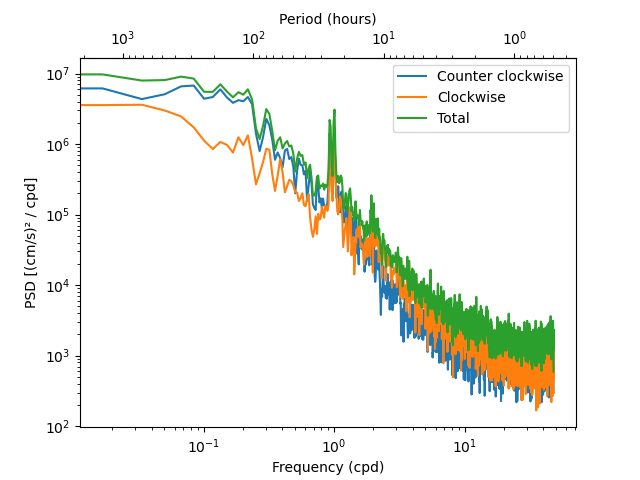

In [12]:
fig = plt.figure()
plt.loglog(freq * 86400, S_ccw, label='Counter clockwise')
plt.loglog(freq * 86400, S_cw,  label='Clockwise')
plt.loglog(freq * 86400, (S_ccw + S_cw), label='Total')
plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

# Grab the current axis to add the secondary axis
ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f

def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')


### CTD data 

In [13]:
df = pd.read_csv('ctd.csv')

# Use station as the only dimension
ds = df.set_index('Station').to_xarray()

In [14]:
ds.sel(Station=1)

<xarray.Dataset> Size: 317kB
Dimensions:                  (Station: 1522)
Coordinates:
  * Station                  (Station) int64 12kB 1 1 1 1 1 1 1 ... 1 1 1 1 1 1
Data variables: (12/25)
    Date                     (Station) object 12kB '2017-12-26' ... '2017-12-26'
    Julian_Day               (Station) float64 12kB 360.8 360.8 ... 360.8 360.8
    ISO_DateTime_UTC         (Station) object 12kB '2017-12-26T19:16:13Z' ......
    Pressure                 (Station) int64 12kB 1 2 3 4 ... 1520 1521 1522
    Depth                    (Station) float64 12kB 0.987 1.979 ... 1.502e+03
    Temperature              (Station) float64 12kB 1.25 1.248 ... 1.809 1.809
    ...                       ...
    Scan_Count               (Station) int64 12kB 12923 13003 ... 63488 64191
    Salinity                 (Station) float64 12kB 33.81 33.81 ... 34.72 34.72
    Salinity_2               (Station) float64 12kB 33.81 33.81 ... 34.73 34.73
    Oxygen_Saturation        (Station) float64 12kB 7.82 7.821 ... 7.662 7.662
    Scans_bin                (Station) int64 12kB 22 45 52 41 44 ... 43 50 47 7
    Flag                     (Station) float64 12kB 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [15]:
# calculate TEOS-10 variables 
import gsw

In [16]:
gsw.pt0_from_t?

Signature: gsw.pt0_from_t(SA, t, p)
Docstring:
Calculates potential temperature with reference pressure, p_ref = 0 dbar.
The present routine is computationally faster than the more general
function "gsw_pt_from_t(SA,t,p,p_ref)" which can be used for any
reference pressure value.
This subroutine calls "gsw_entropy_part(SA,t,p)",
"gsw_entropy_part_zerop(SA,pt0)" and "gsw_gibbs_pt0_pt0(SA,pt0)".

Parameters
----------
SA : array-like
    Absolute Salinity, g/kg
t : array-like
    In-situ temperature (ITS-90), degrees C
p : array-like
    Sea pressure (absolute pressure minus 10.1325 dbar), dbar

Returns
-------
pt0 : array-like, deg C
    potential temperature
    with reference sea pressure (p_ref) = 0 dbar.


References
----------
IOC, SCOR and IAPSO, 2010: The international thermodynamic equation of
seawater - 2010: Calculation and use of thermodynamic properties.
Intergovernmental Oceanographic Commission, Manuals and Guides No. 56,
UNESCO (English), 196 pp.  Available from https://ww

In [ ]:
# calculate absolute salinity 
ds['Absolute_Salinity'] = ('station',gsw.SA_from_SP(ds.Salinity,ds.Pressure,ds.Longitude,ds.Latitude).data)

In [ ]:
# calculate potential temperature 
gsw.pt0_from_t(ds.Absolute_Salinity,ds.Temperature,ds.Pressure)

(1600.0, 0.0)

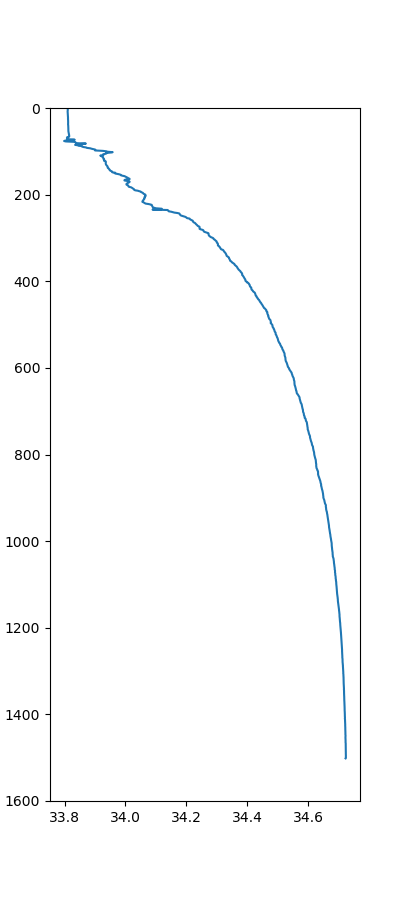

In [17]:
fig = plt.figure(figsize=(4,9))
plt.plot(ds.sel(Station=1).Salinity,ds.sel(Station=1).Depth)
plt.ylim(1600,0)